# Food Delivery Time
---
Analyzing order-level food delivery data (1,000 orders) covering distance, weather, traffic, preparation, courier, and vehicle information.

**Objective**: Build an interpretable regression model to identify which factors drive delivery time, and use its coefficients to recommend where to focus to speed deliveries up.

# Data Understanding

## Import & Load

### Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

from scipy import stats
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import warnings
warnings.filterwarnings('ignore')

os.makedirs('outputs', exist_ok=True)
sns.set_style('whitegrid')

### Load Dataset

In [2]:
df = pd.read_csv('food_delivery_times.csv')

print('Shape:', df.shape)
df.head() # to show the structure of the dataset

Shape: (1000, 9)


,Order_ID,Distance_km,Weather,Traffic_Level,Time_of_Day,Vehicle_Type,Preparation_Time_min,Courier_Experience_yrs,Delivery_Time_min
0,522,7.93,Windy,Low,Afternoon,Scooter,12,1.0,43
1,738,16.42,Clear,Medium,Evening,Bike,20,2.0,84
2,741,9.52,Foggy,Low,Night,Scooter,28,1.0,59
3,661,7.44,Rainy,Medium,Afternoon,Scooter,5,1.0,37
4,412,19.03,Clear,Low,Morning,Bike,16,5.0,68


## Overview

### Data Type Check

In [3]:
df.info()  # check data types and shape
# Order_ID is int64 but it's an identifier, not a measurement
# Weather, Traffic_Level, Time_of_Day, Vehicle_Type are object (categorical), as expected

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Order_ID                1000 non-null   int64  
 1   Distance_km             1000 non-null   float64
 2   Weather                 970 non-null    str    
 3   Traffic_Level           970 non-null    str    
 4   Time_of_Day             970 non-null    str    
 5   Vehicle_Type            1000 non-null   str    
 6   Preparation_Time_min    1000 non-null   int64  
 7   Courier_Experience_yrs  970 non-null    float64
 8   Delivery_Time_min       1000 non-null   int64  
dtypes: float64(2), int64(3), str(4)
memory usage: 70.4 KB


### Summary Statistics

In [34]:
df.describe()

# Courier_Experience_yrs ranges 0-9 years, no negative or unrealistic values
# range of distance is between 0.6 km to 20 km

,Order_ID,Distance_km,Preparation_Time_min,Courier_Experience_yrs,Delivery_Time_min
count,1000.000000,1000.000000,1000.000000,970.000000,1000.000000
mean,500.500000,10.059970,16.982000,4.579381,56.732000
std,288.819436,5.696656,7.204553,2.914394,22.070915
min,1.000000,0.590000,5.000000,0.000000,8.000000
25%,250.750000,5.105000,11.000000,2.000000,41.000000
50%,500.500000,10.190000,17.000000,5.000000,55.500000
75%,750.250000,15.017500,23.000000,7.000000,71.000000
max,1000.000000,19.990000,29.000000,9.000000,153.000000


## Data Consistency Check

In [5]:
for col in ['Weather', 'Traffic_Level', 'Time_of_Day', 'Vehicle_Type']:
    print(col)
    print(df[col].value_counts(dropna=False))
    print()

# Weather: 5 categories + NaN, no typos or inconsistent casing
# Traffic_Level: 3 ordered categories (Low/Medium/High) + NaN, OK
# Time_of_Day: 4 categories + NaN, OK
# Vehicle_Type: 3 categories, no missing values, OK

Weather
Weather
Clear    470
Rainy    204
Foggy    103
Snowy     97
Windy     96
NaN       30
Name: count, dtype: int64

Traffic_Level
Traffic_Level
Medium    390
Low       383
High      197
NaN        30
Name: count, dtype: int64

Time_of_Day
Time_of_Day
Morning      308
Evening      293
Afternoon    284
Night         85
NaN           30
Name: count, dtype: int64

Vehicle_Type
Vehicle_Type
Bike       503
Scooter    302
Car        195
Name: count, dtype: int64



## Missing Values Check

In [35]:
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
print(pd.DataFrame({'missing': missing, 'pct': missing_pct}))
print()

# four columns affected, each ~3% missing: Weather, Traffic_Level, Time_of_Day, Courier_Experience_yrs

                        missing  pct
Order_ID                      0  0.0
Distance_km                   0  0.0
Weather                      30  3.0
Traffic_Level                30  3.0
Time_of_Day                  30  3.0
Vehicle_Type                  0  0.0
Preparation_Time_min          0  0.0
Courier_Experience_yrs       30  3.0
Delivery_Time_min             0  0.0



## Duplicate Check

In [7]:
duplicate_rows = df.duplicated().sum()
print('Duplicate rows:', duplicate_rows)

# no duplicate rows found

Duplicate rows: 0


## Outlier Check

IQR bounds : -4.0 - 116.0 min
Outliers   : 6 (0.60%)



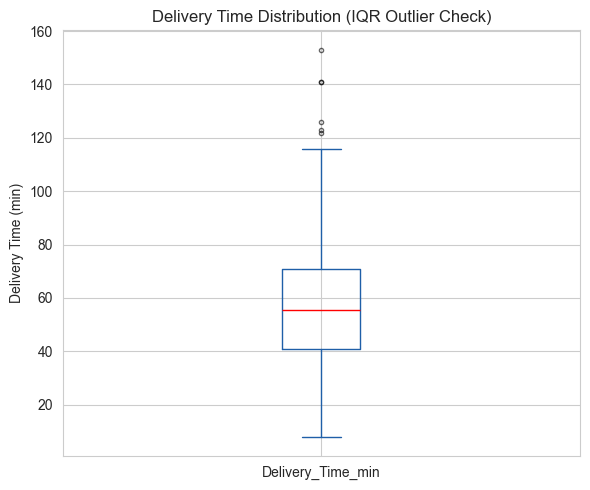

In [37]:
# IQR method on Delivery_Time_min, full dataset
Q1 = df['Delivery_Time_min'].quantile(0.25)
Q3 = df['Delivery_Time_min'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = df[(df['Delivery_Time_min'] < lower_bound) | (df['Delivery_Time_min'] > upper_bound)]
print(f'IQR bounds : {lower_bound:.1f} - {upper_bound:.1f} min')
print(f'Outliers   : {len(outliers)} ({len(outliers)/len(df)*100:.2f}%)')
print()

plt.figure(figsize=(6, 5))
df.boxplot(column='Delivery_Time_min',
           boxprops=dict(color='#1f5fa8'),
           medianprops=dict(color='red'),
           whiskerprops=dict(color='#1f5fa8'),
           capprops=dict(color='#1f5fa8'),
           flierprops=dict(marker='.', color='#d62728', alpha=0.6, markersize=6))
plt.title('Delivery Time Distribution (IQR Outlier Check)')
plt.ylabel('Delivery Time (min)')
plt.tight_layout()
plt.savefig('outputs/01_outlier_boxplot.png', dpi=120, bbox_inches='tight')
plt.show()

# only 6 outliers (0.6%), sitting in Low/Medium traffic rather than High
# reads as long-distance orders that hit light traffic, not data errors -> flagged, not dropped

# Data Preparation

In [9]:
df_clean = df.copy()

# Order_ID is a label, not a numeric value. Keeping it as int lets it leak into describe() with meaningless statistics, so it must be converted to string.
df_clean['Order_ID'] = df_clean['Order_ID'].astype(str)

print('Order_ID dtype :', df_clean['Order_ID'].dtype)
print('Order_ID unique:', df_clean['Order_ID'].nunique(), '/', len(df_clean))
# 1,000 unique IDs for 1,000 rows -> one row per order

Order_ID dtype : str
Order_ID unique: 1000 / 1000


## Missing Values Handling

In [10]:
# categorical columns: fill with the mode (most frequent category)
# ~3% missing each, mode is a safe, low-distortion choice at this scale
for col in ['Weather', 'Traffic_Level', 'Time_of_Day']:
    mode_value = df_clean[col].mode()[0]
    df_clean[col] = df_clean[col].fillna(mode_value)

# Courier_Experience_yrs: fill with the median (unaffected by extreme values)
median_experience = df_clean['Courier_Experience_yrs'].median()
df_clean['Courier_Experience_yrs'] = df_clean['Courier_Experience_yrs'].fillna(median_experience)

print(df_clean.isnull().sum())
# all missing values resolved, 0 rows dropped

Order_ID                  0
Distance_km               0
Weather                   0
Traffic_Level             0
Time_of_Day               0
Vehicle_Type              0
Preparation_Time_min      0
Courier_Experience_yrs    0
Delivery_Time_min         0
dtype: int64


## Feature Engineering

In [11]:
# Traffic_Level as an ordinal score, so traffic can be used as a numeric severity measure
traffic_map = {'Low': 1, 'Medium': 2, 'High': 3}
df_clean['Traffic_Level_Score'] = df_clean['Traffic_Level'].map(traffic_map)

# Courier experience buckets, easier to read in category comparisons than raw years
def experience_bucket(years):
    if years <= 2:
        return 'Novice (0-2 yrs)'
    elif years <= 5:
        return 'Intermediate (3-5 yrs)'
    return 'Experienced (6+ yrs)'

df_clean['Experience_Level'] = df_clean['Courier_Experience_yrs'].apply(experience_bucket)

# Distance buckets, for category-level comparison alongside the continuous variable
def distance_bucket(km):
    if km <= 7:
        return 'Short (<=7km)'
    elif km <= 14:
        return 'Medium (7-14km)'
    return 'Long (>14km)'

df_clean['Distance_Category'] = df_clean['Distance_km'].apply(distance_bucket)

# Peak hour flag: Morning and Evening carry the highest typical order volume for food delivery
df_clean['Is_Peak_Hour'] = df_clean['Time_of_Day'].isin(['Morning', 'Evening']).astype(int)

df_clean[['Traffic_Level', 'Traffic_Level_Score', 'Experience_Level', 'Distance_Category', 'Is_Peak_Hour']].head()

,Traffic_Level,Traffic_Level_Score,Experience_Level,Distance_Category,Is_Peak_Hour
0,Low,1,Novice (0-2 yrs),Medium (7-14km),0
1,Medium,2,Novice (0-2 yrs),Long (>14km),1
2,Low,1,Novice (0-2 yrs),Medium (7-14km),0
3,Medium,2,Novice (0-2 yrs),Medium (7-14km),0
4,Low,1,Intermediate (3-5 yrs),Long (>14km),1


# Cleaning Summary

In [12]:
print(f'Raw rows           : {len(df):,}')
print(f'Rows after cleaning : {len(df_clean):,}')
print(f'Rows removed        : {len(df) - len(df_clean)}')
print(f'Columns added       : {df_clean.shape[1] - df.shape[1]}')
print()
df_clean.head()

Raw rows           : 1,000
Rows after cleaning : 1,000
Rows removed        : 0
Columns added       : 4



,Order_ID,Distance_km,Weather,Traffic_Level,Time_of_Day,Vehicle_Type,Preparation_Time_min,Courier_Experience_yrs,Delivery_Time_min,Traffic_Level_Score,Experience_Level,Distance_Category,Is_Peak_Hour
0,522,7.93,Windy,Low,Afternoon,Scooter,12,1.0,43,1,Novice (0-2 yrs),Medium (7-14km),0
1,738,16.42,Clear,Medium,Evening,Bike,20,2.0,84,2,Novice (0-2 yrs),Long (>14km),1
2,741,9.52,Foggy,Low,Night,Scooter,28,1.0,59,1,Novice (0-2 yrs),Medium (7-14km),0
3,661,7.44,Rainy,Medium,Afternoon,Scooter,5,1.0,37,2,Novice (0-2 yrs),Medium (7-14km),0
4,412,19.03,Clear,Low,Morning,Bike,16,5.0,68,1,Intermediate (3-5 yrs),Long (>14km),1


# Exploratory Data Analysis

## Overview

In [39]:
print(f'Total orders      : {len(df_clean):,}')
print(f'Total columns     : {df_clean.shape[1]}')
print()

Total orders      : 1,000
Total columns     : 13



## Distribution Check

### Numeric Distribution

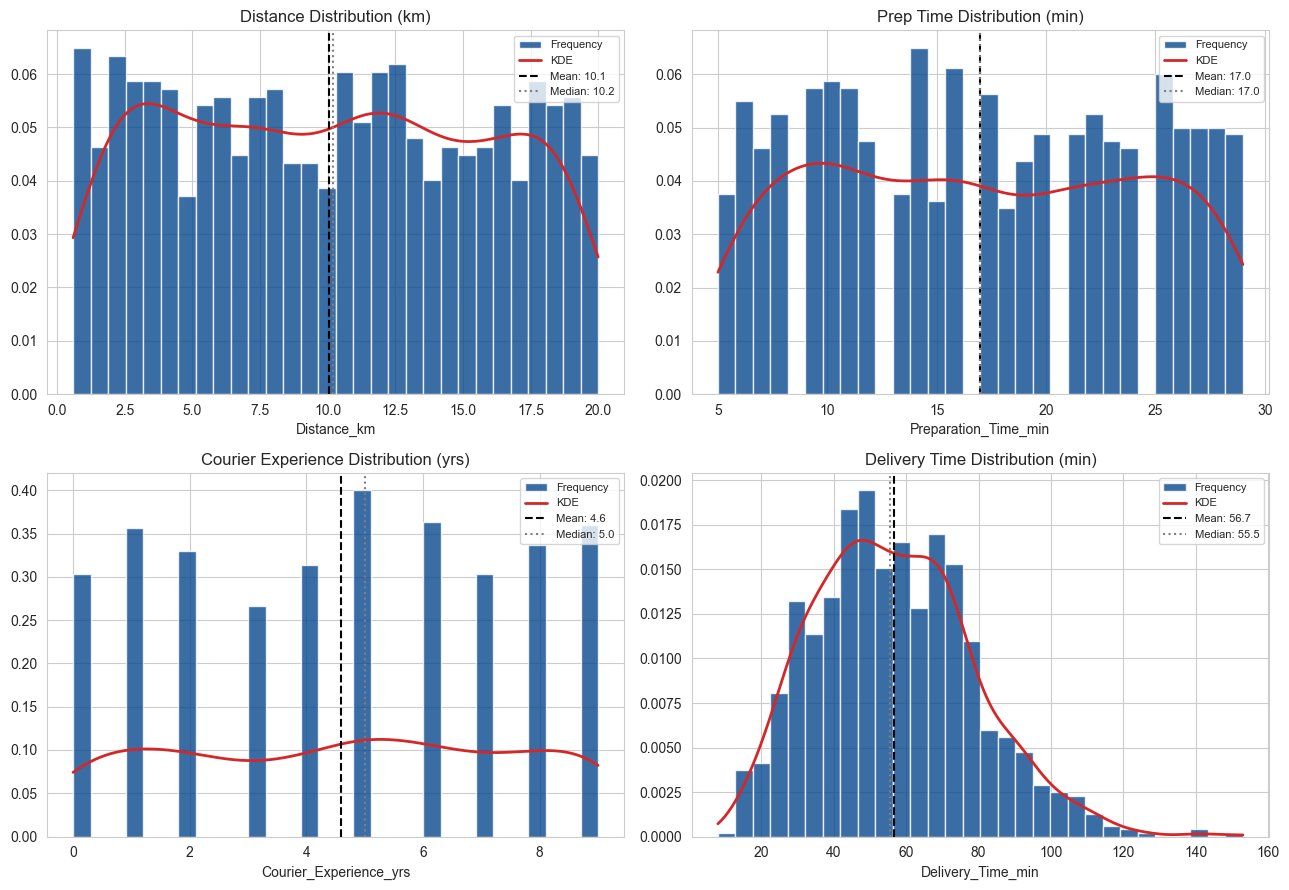

In [14]:
cols = ['Distance_km', 'Preparation_Time_min', 'Courier_Experience_yrs', 'Delivery_Time_min']
titles = ['Distance Distribution (km)', 'Prep Time Distribution (min)',
          'Courier Experience Distribution (yrs)', 'Delivery Time Distribution (min)']

fig, axes = plt.subplots(2, 2, figsize=(13, 9))
axes = axes.flatten()

for ax, col, title in zip(axes, cols, titles):
    ax.hist(df_clean[col], bins=30, color=sns.color_palette('Blues', 10)[-1],
            edgecolor='white', density=True, alpha=0.8, label='Frequency')
    kde_x = np.linspace(df_clean[col].min(), df_clean[col].max(), 300)
    kde = stats.gaussian_kde(df_clean[col])
    ax.plot(kde_x, kde(kde_x), color='#d62728', lw=2, label='KDE')
    ax.axvline(df_clean[col].mean(), color='black', lw=1.5, linestyle='--',
               label=f'Mean: {df_clean[col].mean():.1f}')
    ax.axvline(df_clean[col].median(), color='gray', lw=1.5, linestyle=':',
               label=f'Median: {df_clean[col].median():.1f}')
    ax.set_title(title)
    ax.set_xlabel(col)
    ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig('outputs/02b_numeric_distributions_grid.png', dpi=120, bbox_inches='tight')
plt.show()
# Distance, Prep time, Courier experience: flat/uniform, mean ~ median -> not skewed
# Delivery time: right-skewed, mean (56.7) > median (55.5), long tail from long outlier deliveries

### Categorical Distribution

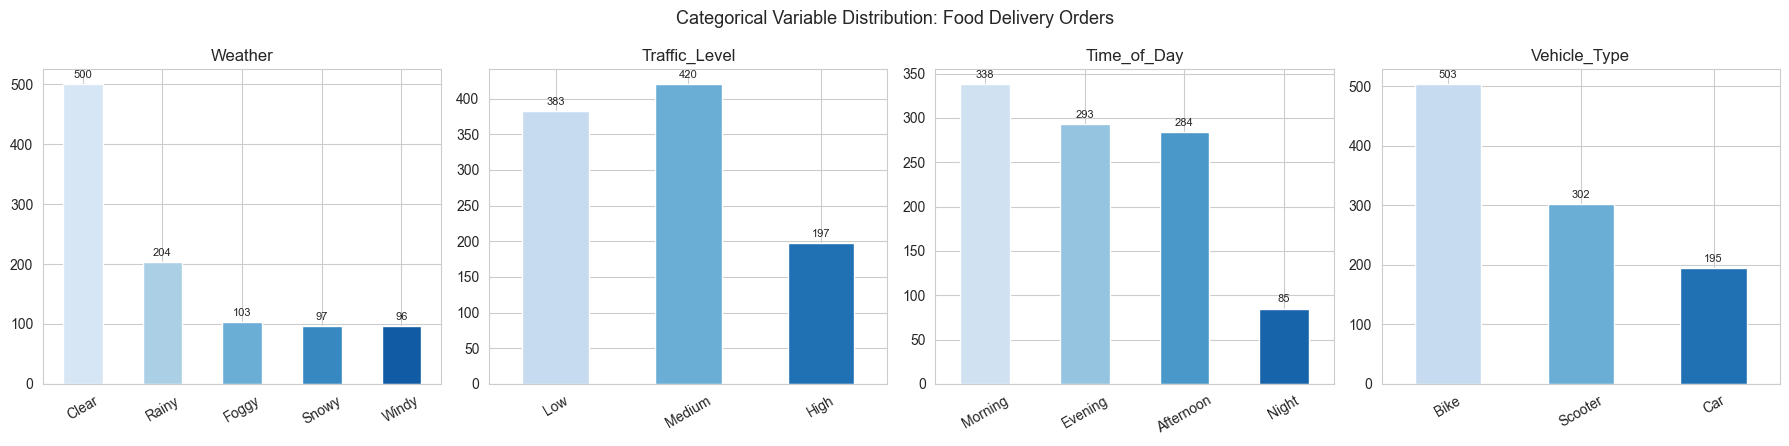

In [15]:
fig, axes = plt.subplots(1, 4, figsize=(18, 4.5))
fig.suptitle('Categorical Variable Distribution: Food Delivery Orders', fontsize=13)

cat_cols = ['Weather', 'Traffic_Level', 'Time_of_Day', 'Vehicle_Type']
order_map = {'Traffic_Level': ['Low', 'Medium', 'High']}

for ax, col in zip(axes, cat_cols):
    vc = df_clean[col].value_counts()
    if col in order_map:
        vc = vc.reindex(order_map[col])
    vc.plot(kind='bar', ax=ax, color=sns.color_palette('Blues', len(vc)))
    ax.bar_label(ax.containers[0], padding=3, fontsize=8)
    ax.set_title(col)
    ax.set_xlabel('')
    ax.tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.savefig('outputs/03_categorical_distribution.png', dpi=120, bbox_inches='tight')
plt.show()

# Weather : Clear dominates, Snowy/Foggy least common -> fewer observations for extreme-weather effects
# Traffic_Level : Medium and Low are close, High is the smallest group
# Vehicle_Type : Bike is the most common courier vehicle

## Bivariate & Multivariate Analysis

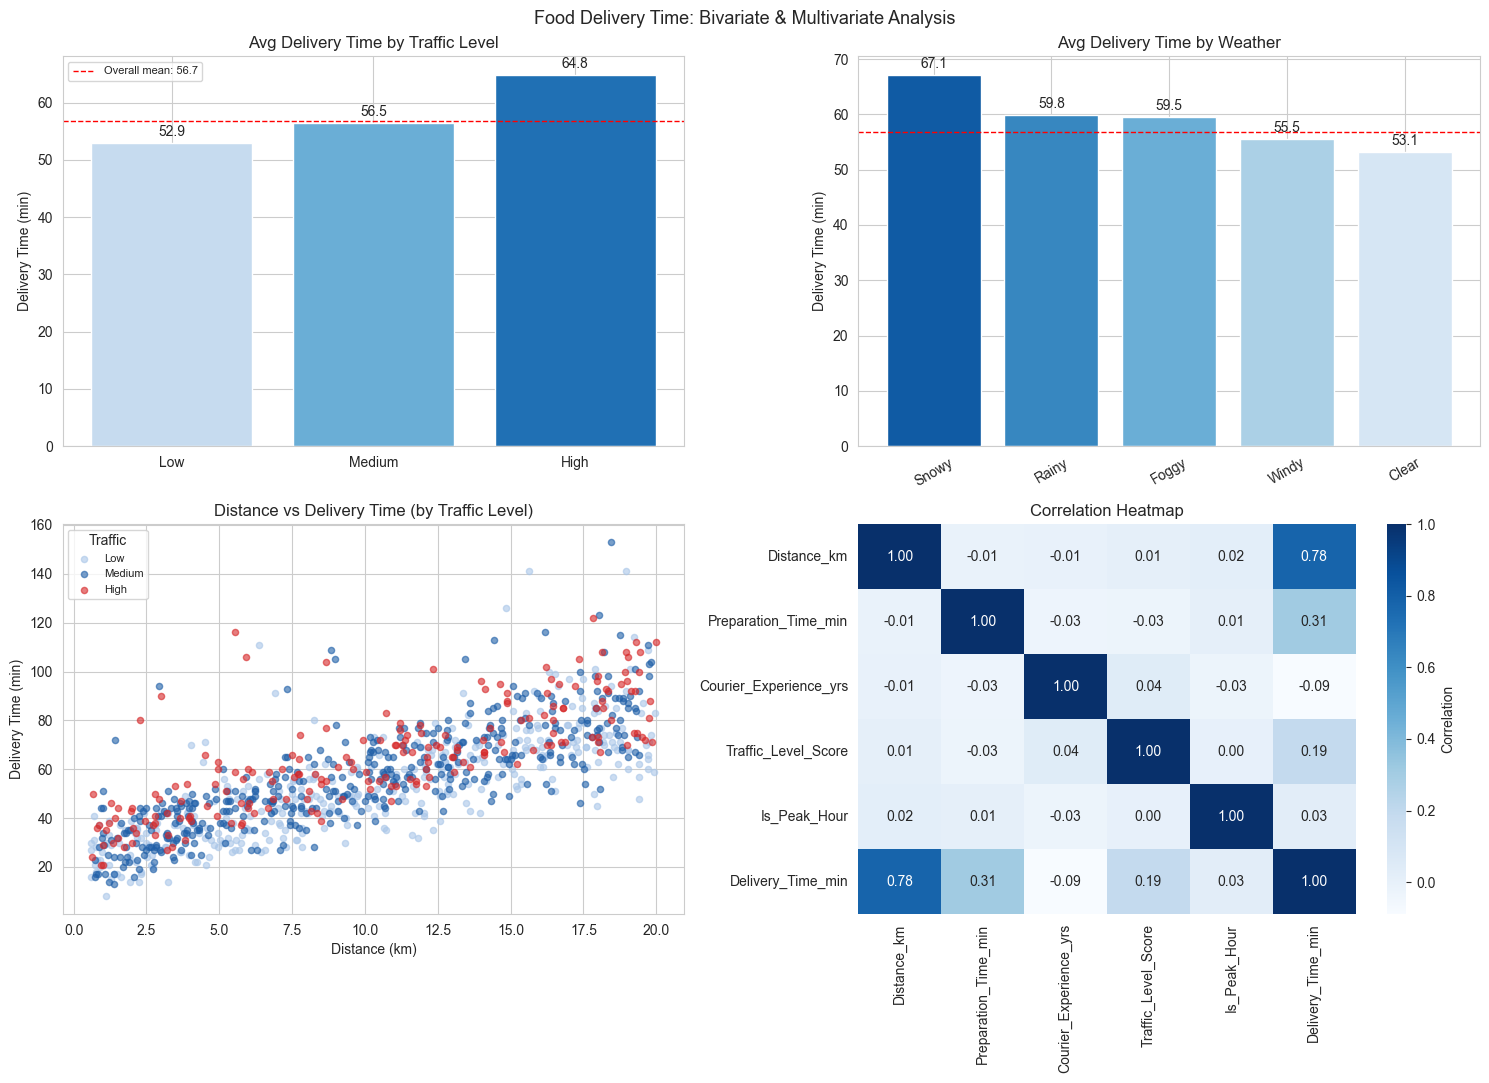

In [16]:
fig, axes = plt.subplots(2, 2, figsize=(15, 11))
fig.suptitle('Food Delivery Time: Bivariate & Multivariate Analysis', fontsize=13)

# Chart 1: avg delivery time by traffic level
traffic_avg = df_clean.groupby('Traffic_Level')['Delivery_Time_min'].mean().reindex(['Low', 'Medium', 'High'])
axes[0, 0].bar(traffic_avg.index, traffic_avg.values, color=sns.color_palette('Blues', 3))
axes[0, 0].bar_label(axes[0, 0].containers[0], fmt='%.1f', padding=3)
axes[0, 0].axhline(df_clean['Delivery_Time_min'].mean(), color='red', linestyle='--',
                   linewidth=1, label=f"Overall mean: {df_clean['Delivery_Time_min'].mean():.1f}")
axes[0, 0].set_title('Avg Delivery Time by Traffic Level')
axes[0, 0].set_ylabel('Delivery Time (min)')
axes[0, 0].legend(fontsize=8)

# Chart 2: avg delivery time by weather
weather_avg = df_clean.groupby('Weather')['Delivery_Time_min'].mean().sort_values(ascending=False)
axes[0, 1].bar(weather_avg.index, weather_avg.values,
               color=sns.color_palette('Blues', len(weather_avg))[::-1])
axes[0, 1].bar_label(axes[0, 1].containers[0], fmt='%.1f', padding=3)
axes[0, 1].axhline(df_clean['Delivery_Time_min'].mean(), color='red', linestyle='--', linewidth=1)
axes[0, 1].set_title('Avg Delivery Time by Weather')
axes[0, 1].set_ylabel('Delivery Time (min)')
axes[0, 1].tick_params(axis='x', rotation=30)

# Chart 3: distance vs delivery time, colored by traffic
colors = {'Low': '#a9c6e8', 'Medium': '#1f5fa8', 'High': '#d62728'}
for level, color in colors.items():
    sub = df_clean[df_clean['Traffic_Level'] == level]
    axes[1, 0].scatter(sub['Distance_km'], sub['Delivery_Time_min'],
                       color=color, alpha=0.6, s=20, label=level)
axes[1, 0].set_title('Distance vs Delivery Time (by Traffic Level)')
axes[1, 0].set_xlabel('Distance (km)')
axes[1, 0].set_ylabel('Delivery Time (min)')
axes[1, 0].legend(fontsize=8, title='Traffic')

# Chart 4: correlation heatmap
corr_cols = ['Distance_km', 'Preparation_Time_min', 'Courier_Experience_yrs',
             'Traffic_Level_Score', 'Is_Peak_Hour', 'Delivery_Time_min']
sns.heatmap(df_clean[corr_cols].corr(), annot=True, fmt='.2f', cmap='Blues', ax=axes[1, 1],
            cbar_kws={'label': 'Correlation'})
axes[1, 1].set_title('Correlation Heatmap')

plt.tight_layout()
plt.savefig('outputs/04_bivariate_multivariate.png', dpi=120, bbox_inches='tight')
plt.show()

# Chart 1: delivery time climbs Low -> Medium -> High traffic, the largest categorical swing
# Chart 2: Snowy and Foggy orders run longest, Clear weather is fastest
# Chart 3: distance is the dominant relationship, almost linear where traffic shifts the line up/down rather than changing its slope
# Chart 4: Distance_km has the strongest correlation with Delivery_Time_min followed by Preparation_Time_min

## Target Variable

Delivery time is the only variable that correlates with the others, while the inputs barely correlate among themselves.
That is the signature of a dependent variable. Delivery time is chosen as target variable in this analysis.

# Export #1

In [17]:
export_cols = ['Order_ID', 'Distance_km', 'Weather', 'Traffic_Level', 'Time_of_Day',
               'Vehicle_Type', 'Preparation_Time_min', 'Courier_Experience_yrs',
               'Delivery_Time_min', 'Traffic_Level_Score', 'Experience_Level',
               'Distance_Category', 'Is_Peak_Hour']
delivery_export = df_clean[export_cols].copy()

with pd.ExcelWriter('outputs/Delivery_Dashboard_Data.xlsx', engine='openpyxl') as writer:
    delivery_export.to_excel(writer, sheet_name='Delivery_Clean', index=False)

print('Exported: outputs/Delivery_Dashboard_Data.xlsx')
print(f'  Delivery_Clean : {delivery_export.shape}')

Exported: outputs/Delivery_Dashboard_Data.xlsx
  Delivery_Clean : (1000, 13)


# Modeling

## Train / Test Split

In [18]:
feature_cols = ['Distance_km', 'Preparation_Time_min', 'Courier_Experience_yrs',
                'Weather', 'Traffic_Level', 'Time_of_Day', 'Vehicle_Type']

X = df_clean[feature_cols].copy()
y = df_clean['Delivery_Time_min'].copy()

categorical_cols = ['Weather', 'Traffic_Level', 'Time_of_Day', 'Vehicle_Type']
X_encoded = pd.get_dummies(X, columns=categorical_cols, drop_first=True)

X_train, X_test, y_train, y_test = train_test_split(X_encoded, y, test_size=0.2, random_state=42)

print('Train rows:', X_train.shape[0])
print('Test rows :', X_test.shape[0])
print('Features  :', X_train.shape[1])

Train rows: 800
Test rows : 200
Features  : 14


## Encoding

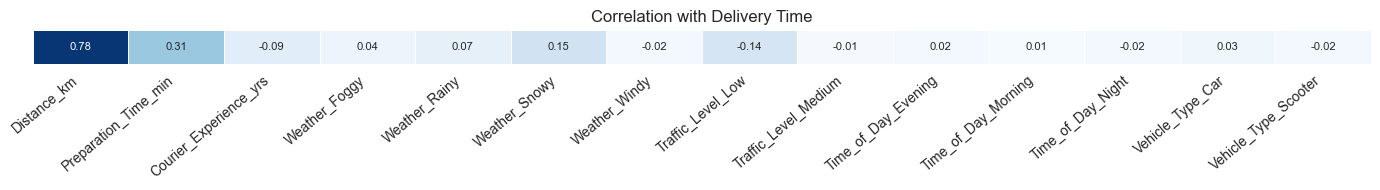

In [19]:
corr_df = X_encoded.copy()
corr_df['Delivery_Time_min'] = y

target_corr = corr_df.corr()[['Delivery_Time_min']].drop('Delivery_Time_min').T
color_vals = target_corr.abs()   

plt.figure(figsize=(14, 2))
sns.heatmap(color_vals, annot=target_corr, fmt='.2f', cmap='Blues', vmin=0, vmax=0.8,
            linewidths=0.5, cbar=False, annot_kws={'size': 8}, linecolor='white')
plt.title('Correlation with Delivery Time')
plt.yticks([])
plt.xticks(rotation=40, ha='right')
plt.tight_layout()
plt.show()

## Baseline

In [40]:
# a mean-only prediction
baseline_pred = pd.Series(y_train.mean(), index=y_test.index)

baseline_mae = mean_absolute_error(y_test, baseline_pred)
baseline_rmse = np.sqrt(mean_squared_error(y_test, baseline_pred))

print(f'MAE  : {baseline_mae:.2f}')
print(f'RMSE : {baseline_rmse:.2f}')

MAE  : 17.50
RMSE : 21.23


## Linear Regression

In [21]:
lin_reg = LinearRegression()
lin_reg.fit(X_train, y_train)
y_pred_lr = lin_reg.predict(X_test)

lr_mae = mean_absolute_error(y_test, y_pred_lr)
lr_rmse = np.sqrt(mean_squared_error(y_test, y_pred_lr))
lr_r2 = r2_score(y_test, y_pred_lr)

print(f'MAE  : {lr_mae:.2f}')
print(f'RMSE : {lr_rmse:.2f}')
print(f'R2   : {lr_r2:.3f}')

MAE  : 5.90 min
RMSE : 8.83 min
R2   : 0.826


### Linear Regressions Coefficients 

In [22]:
coef_table = pd.DataFrame({
    'feature': X_encoded.columns,
    'coefficient': lin_reg.coef_
}).sort_values('coefficient', ascending=False)

print(coef_table.to_string(index=False))

# each coefficient is the effect of one unit of that feature, in its own units
# Distance_km +3.0 = +3 min per km ; Preparation_Time_min +0.97 = +0.97 min per minute of prep
# these units differ, so we cannot yet rank drivers off this table directly (different unit of measurement in each features)

               feature  coefficient
         Weather_Snowy     9.246816
         Weather_Foggy     5.816452
         Weather_Rainy     4.639445
           Distance_km     3.001304
         Weather_Windy     1.446947
   Time_of_Day_Evening     1.004784
  Preparation_Time_min     0.969158
      Vehicle_Type_Car     0.517729
   Time_of_Day_Morning    -0.169274
Courier_Experience_yrs    -0.677165
  Vehicle_Type_Scooter    -0.934973
     Time_of_Day_Night    -1.375483
  Traffic_Level_Medium    -5.453584
     Traffic_Level_Low   -11.125629


### Features Ranking (Impact in Minutes)

In [41]:
# Collapse the one-hot dummies back to their original factor and express each factor's
# presented as the MAX minutes it can add to delivery time
raw = pd.Series(lin_reg.coef_, index=X_encoded.columns)

impact = {}
for feat in ['Distance_km', 'Preparation_Time_min', 'Courier_Experience_yrs']:
    span = df_clean[feat].max() - df_clean[feat].min()
    impact[feat] = abs(raw[feat] * span)
for prefix in ['Weather', 'Traffic_Level', 'Time_of_Day', 'Vehicle_Type']:
    effects = [raw[c] for c in X_encoded.columns if c.startswith(prefix)] + [0.0]
    impact[prefix] = max(effects) - min(effects)

col = {'Distance_km': 'Distance', 'Preparation_Time_min': 'Prep time',
        'Courier_Experience_yrs': 'Courier experience', 'Traffic_Level': 'Traffic',
        'Weather': 'Weather', 'Time_of_Day': 'Time of day', 'Vehicle_Type': 'Vehicle type'}

impact_table = (pd.Series(impact, name='max_minutes_impact')
                .sort_values(ascending=False)
                .reset_index()
                .rename(columns={'index': 'factor'}))
impact_table['label'] = impact_table['factor'].map(col)

print(impact_table[['label', 'max_minutes_impact']].round(1).to_string(index=False))

# Distance dominates, then Prep time, then Traffic.

             label  max_minutes_impact
          Distance                58.2
         Prep time                23.3
           Traffic                11.1
           Weather                 9.2
Courier experience                 6.1
       Time of day                 2.4
      Vehicle type                 1.5


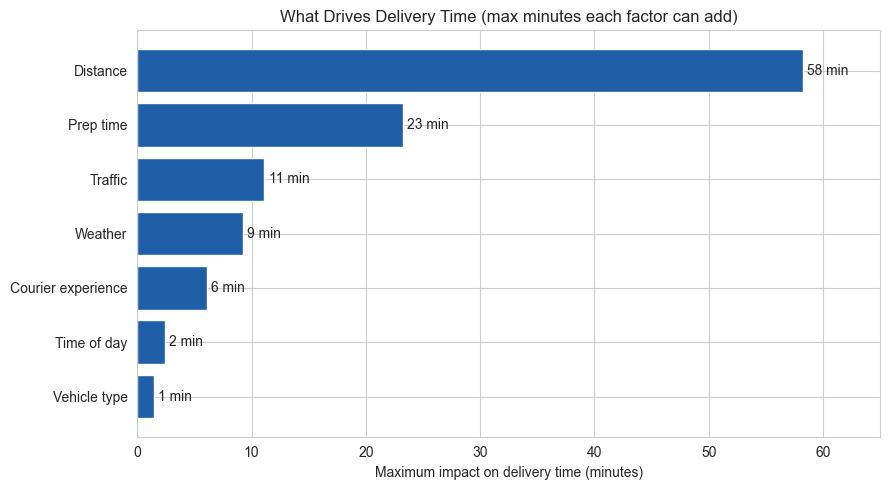

In [24]:
plot_df = impact_table.sort_values('max_minutes_impact')

plt.figure(figsize=(9, 5))
bars = plt.barh(plot_df['label'], plot_df['max_minutes_impact'], color='#1f5fa8')
plt.bar_label(bars, fmt='%.0f min', padding=3, fontsize=10)
plt.title('What Drives Delivery Time (max minutes each factor can add)', fontsize=12)
plt.xlabel('Maximum impact on delivery time (minutes)')
plt.xlim(0, 65)
plt.tight_layout()
plt.savefig('outputs/05_driver_impact.png', dpi=120, bbox_inches='tight')
plt.show()

## Random Forest (Comparison Analysis)

In [25]:
rf_reg = RandomForestRegressor(n_estimators=200, random_state=42)
rf_reg.fit(X_train, y_train)
y_pred_rf = rf_reg.predict(X_test)

rf_mae = mean_absolute_error(y_test, y_pred_rf)
rf_rmse = np.sqrt(mean_squared_error(y_test, y_pred_rf))
rf_r2 = r2_score(y_test, y_pred_rf)

print(f'MAE  : {rf_mae:.2f} min')
print(f'RMSE : {rf_rmse:.2f} min')
print(f'R2   : {rf_r2:.3f}')

MAE  : 7.02 min
RMSE : 10.22 min
R2   : 0.767


## Model Comparison

In [26]:
comparison = pd.DataFrame({
    'Model': ['Baseline (mean)', 'Linear Regression', 'Random Forest'],
    'MAE': [round(baseline_mae, 2), round(lr_mae, 2), round(rf_mae, 2)],
    'RMSE': [round(baseline_rmse, 2), round(lr_rmse, 2), round(rf_rmse, 2)],
    'R2': [np.nan, round(lr_r2, 3), round(rf_r2, 3)]
}).sort_values('MAE').reset_index(drop=True)

print(comparison.to_string(index=False))

# both models beat the mean baseline.
# Linear Regression has the lowest MAE/RMSE and highest R2, and its coefficients are directly interpretable
# Therefore selected as the primary model. Random Forest served to confirm the simpler model is not underfitting. (benchmarking)

            Model   MAE  RMSE    R2
Linear Regression  5.90  8.83 0.826
    Random Forest  7.02 10.22 0.767
  Baseline (mean) 17.50 21.23   NaN


# Export #2

In [42]:
model_comparison_export = comparison.copy()

driver_impact_export = impact_table[['label', 'factor', 'max_minutes_impact']].copy()
driver_impact_export.columns = ['Factor', 'Raw_Column', 'Max_Minutes_Impact']

coefficients_export = coef_table.copy()
coefficients_export.columns = ['Feature', 'Coefficient_Min']

with pd.ExcelWriter('outputs/Delivery_Dashboard2_Drivers.xlsx', engine='openpyxl') as writer:
    model_comparison_export.to_excel(writer, sheet_name='Model_Comparison', index=False)
    driver_impact_export.to_excel(writer, sheet_name='Driver_Impact', index=False)
    coefficients_export.to_excel(writer, sheet_name='Coefficients', index=False)

print('Exported: outputs/Delivery_Dashboard2_Drivers.xlsx')

Exported: outputs/Delivery_Dashboard2_Drivers.xlsx


# Final Summary

**Key Result**

Distance and preparation time are the dominant drivers, with traffic and weather as real secondary effects. Courier experience barely moves delivery time, so seniority is not a useful lever.

**Limitations**
- No time dimension: Time_of_Day is categorical, not a timestamp, so trend or seasonality effects can't be analyzed.
- No actual data on route history that may allow optimization routes analysis.